# OpenVINO lab: car detection + color classification

Teaching flow: **Core** → **read_model** → **compile_model** → **inference**. 

[OpenVINO 2026](https://docs.openvino.ai/2026/index.html), 

[hello-world](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/notebooks/hello-world/hello-world.ipynb)

Add **FP32**, **FP16**, **INT8** under `models/` when available.


In [1]:
import json
import os
import time
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
import openvino as ov

BASE = Path(os.environ.get("OV_DEPLOY_BASE", os.environ.get("GETI_DEPLOY_BASE", "."))).resolve()
MODELS = BASE / "models"
THRESHOLD = 0.225
DEVICE_DETECTION = "GPU"
DEVICE_CLASSIFICATION = "CPU"
# Classification mean/scale: benchmark_utils.MEAN_RGB / SCALE_RGB (same values as Geti).

def load_labels(model_dir: Path):
    p = model_dir / "config.json"
    if not p.exists():
        return []
    with open(p, encoding="utf-8") as f:
        cfg = json.load(f)
    raw = cfg.get("model_parameters", {}).get("labels", "") or ""
    return [s.strip() for s in raw.split()]

def precision_dirs():
    out = []
    for name in ("FP32", "FP16", "INT8"):
        det = MODELS / name / "Detection" / "model.xml"
        cls = MODELS / name / "Classification" / "model.xml"
        if det.is_file() and cls.is_file():
            out.append(name)
    return out

print("BASE:", BASE)
print("Precision folders:", precision_dirs() or "(none)")


BASE: C:\Users\anish\Cursor\Openvino\DevCon\geti_sdk-deployment\detection_classification\1
Precision folders: ['INT8']


## 1. Initialize Runtime


In [2]:
core = ov.Core()
print("ready")


ready


## 2. Available devices


In [3]:
print(core.available_devices)


['CPU', 'GPU', 'NPU']


## 3. Model paths


In [4]:
available = precision_dirs()
if not available:
    raise FileNotFoundError(MODELS)
LAB_PRECISION = available[0]
detection_model_path = MODELS / LAB_PRECISION / "Detection" / "model.xml"
classification_model_path = MODELS / LAB_PRECISION / "Classification" / "model.xml"
print(LAB_PRECISION)
print(detection_model_path)
print(classification_model_path)
detection_label = load_labels(detection_model_path.parent)
detection_label = detection_label[0] if detection_label else "CAR"
classification_labels = load_labels(classification_model_path.parent)


INT8
C:\Users\anish\Cursor\Openvino\DevCon\geti_sdk-deployment\detection_classification\1\models\INT8\Detection\model.xml
C:\Users\anish\Cursor\Openvino\DevCon\geti_sdk-deployment\detection_classification\1\models\INT8\Classification\model.xml


## 4. Compile models

In [5]:
detection_model = core.read_model(detection_model_path)
classification_model = core.read_model(classification_model_path)
compiled_detection = core.compile_model(model=detection_model, device_name=DEVICE_DETECTION)
compiled_classification = core.compile_model(model=classification_model, device_name=DEVICE_CLASSIFICATION)
# print(compiled_detection)
# print(compiled_classification)


## 5. Load image


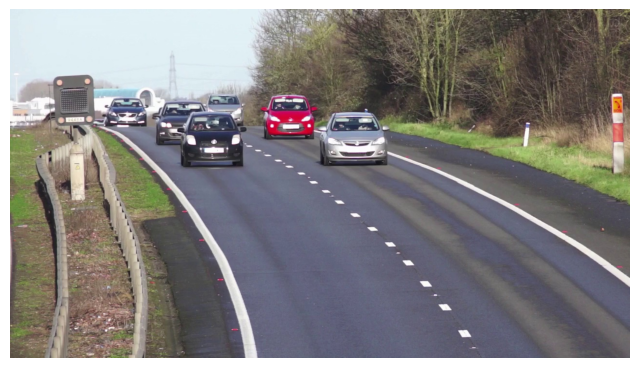

In [6]:
image_path = BASE / "media" / "sample_image_1.jpg"
if not image_path.is_file():
    raise FileNotFoundError(image_path)
image_bgr = cv2.imread(str(image_path))
assert image_bgr is not None
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


## 6. Preprocess (detection)


In [7]:
detection_input = compiled_detection.input(0)
detection_input_shape = detection_input.get_partial_shape()
input_h = int(detection_input_shape[2].get_length()) if detection_input_shape[2].is_static else 800
input_w = int(detection_input_shape[3].get_length()) if detection_input_shape[3].is_static else 992
orig_h, orig_w = image_bgr.shape[:2]
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
resized = cv2.resize(image_rgb, (input_w, input_h))
normalized = resized.astype(np.float32) / 255.0
input_tensor_detection = np.expand_dims(normalized.transpose(2, 0, 1), axis=0).astype(np.float32)
print(input_tensor_detection.shape)


(1, 3, 800, 992)


## 7. Detection inference


In [8]:
t0 = time.time()
detection_output = compiled_detection([input_tensor_detection])
t1 = time.time()
print(f"Detection latency ms: {(t1 - t0) * 1000:.2f}")


Detection latency ms: 35.31


## 8. Postprocess


Detections: 3


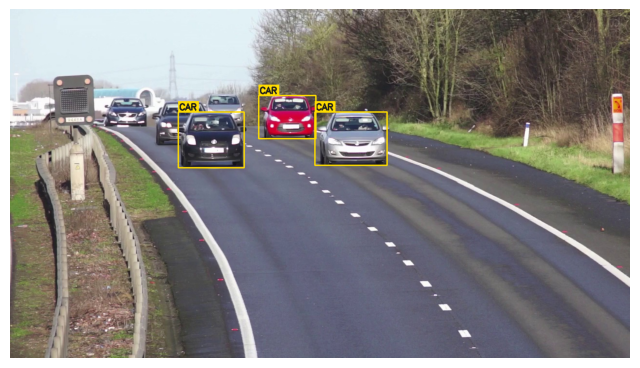

In [9]:
def parse_detection_output(output_dict):
    out_by_name = {}
    for k, v in output_dict.items():
        name = k.get_any_name() if hasattr(k, "get_any_name") else str(k)
        out_by_name[name.lower()] = np.array(v)
    boxes_arr = out_by_name.get("boxes")
    if boxes_arr is None:
        boxes_arr = np.squeeze(list(output_dict.values())[0])
    boxes_arr = np.squeeze(boxes_arr)
    if boxes_arr.ndim == 3:
        boxes_arr = boxes_arr.reshape(-1, 5)
    return boxes_arr

def boxes_to_original(boxes_arr, orig_h, orig_w, input_h, input_w, thresh):
    rb, rs = [], []
    if boxes_arr.ndim != 2 or boxes_arr.shape[1] != 5:
        return np.zeros((0, 4)), np.zeros(0)
    for i in range(len(boxes_arr)):
        x1, y1, x2, y2, conf = boxes_arr[i]
        if conf < thresh:
            continue
        bx1 = int(np.clip(x1 / input_w * orig_w, 0, orig_w))
        by1 = int(np.clip(y1 / input_h * orig_h, 0, orig_h))
        bx2 = int(np.clip(x2 / input_w * orig_w, 0, orig_w))
        by2 = int(np.clip(y2 / input_h * orig_h, 0, orig_h))
        if (bx2 - bx1) * (by2 - by1) > 1 and bx2 > bx1 and by2 > by1:
            rb.append([bx1, by1, bx2, by2])
            rs.append(float(conf))
    return (np.array(rb) if rb else np.zeros((0, 4)), np.array(rs) if rs else np.zeros(0))

boxes_raw = parse_detection_output(detection_output)
detection_boxes, _ = boxes_to_original(boxes_raw, orig_h, orig_w, input_h, input_w, THRESHOLD)
print("Detections:", len(detection_boxes))
det_label_draw = str(detection_label).upper() if detection_label else "CAR"
vis = image_bgr.copy()
for b in detection_boxes:
    x1, y1, x2, y2 = map(int, b)
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 220, 255), 2)
    (tw, th), _ = cv2.getTextSize(det_label_draw, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
    cv2.rectangle(vis, (x1, y1 - th - 8), (x1 + tw + 4, y1), (0, 220, 255), -1)
    cv2.putText(vis, det_label_draw, (x1 + 2, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (30, 30, 30), 2)
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


## 9. Classification

**Detection** already ran in sections 7–8 (`detection_output` → `detection_boxes`). This cell only runs the **classification** model on each crop.


Classification total ms: 22.91
CAR - Silver
CAR - Black
CAR - Red


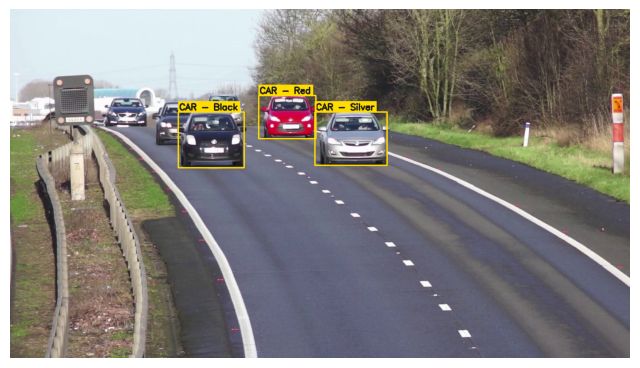

In [10]:
from benchmark_utils import classify_crops_with_labels

color_names, total_cls_ms = classify_crops_with_labels(
    compiled_classification,
    image_bgr,
    detection_boxes,
    classification_labels,
    detection_label=detection_label,
)
if len(detection_boxes):
    print(f"Classification total ms: {total_cls_ms:.2f}")
for t in color_names:
    print(t)
final_vis = image_bgr.copy()
for i, box in enumerate(detection_boxes):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(final_vis, (x1, y1), (x2, y2), (0, 220, 255), 2)
    text = color_names[i] if i < len(color_names) else ""
    (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
    cv2.rectangle(final_vis, (x1, y1 - th - 8), (x1 + tw + 4, y1), (0, 220, 255), -1)
    cv2.putText(final_vis, text, (x1 + 2, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (30, 30, 30), 2)
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(final_vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


## Try your own image


In [11]:
# image_path = Path(r"C:/path/to/image.jpg")


## Benchmark (INT8)

Set **`BENCHMARK_PRECISION`** (default **INT8**). **`benchmark_utils.benchmark_two_stage_per_device`** uses a **fair** split: **detection** on **`shared_detection_device`** (default **GPU** if available, else **CPU**); each row only changes **where classification runs**. **Default rows: CPU and GPU** (NPU is not included). Pass ``devices=[..., \"NPU\"]`` into the helper if you want an NPU row. **`Det@` / `Cls@`** show actual device placement.


Benchmark precision: INT8
Cls_on     Det@   Cls@     Det_ms     Cls_ms   Total_ms Boxes
------------------------------------------------------------------------------
CPU         GPU    CPU      50.49      16.83      67.32     3
GPU         GPU    GPU      18.49      11.28      29.77     3
NPU         GPU    NPU      18.02       7.40      25.42     3


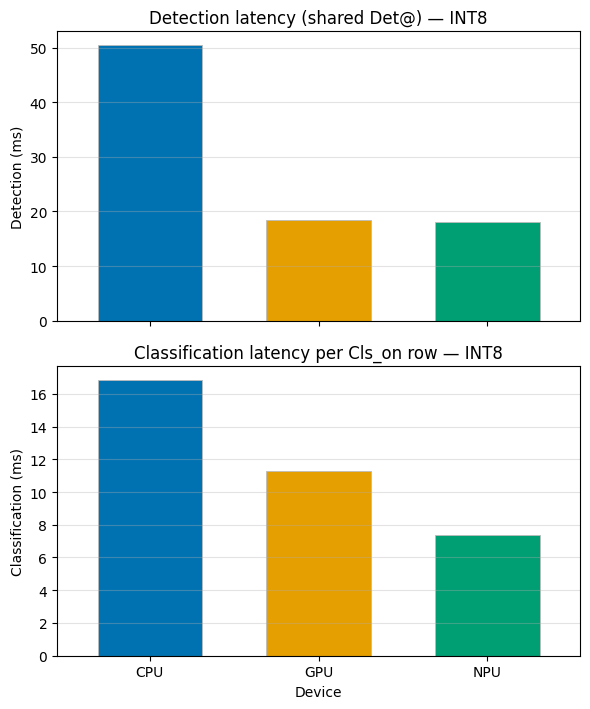

In [13]:
from benchmark_utils import (
    benchmark_two_stage_per_device,
    print_two_stage_benchmark_table,
    plot_benchmark_det_cls,
)

BENCHMARK_PRECISION = "INT8"
detection_xml = MODELS / BENCHMARK_PRECISION / "Detection" / "model.xml"
classification_xml = MODELS / BENCHMARK_PRECISION / "Classification" / "model.xml"
if not detection_xml.is_file() or not classification_xml.is_file():
    raise FileNotFoundError(
        f"Need Detection + Classification IRs under models/{BENCHMARK_PRECISION}/"
    )

rows = benchmark_two_stage_per_device(
    core,
    detection_xml,
    classification_xml,
    image_bgr,
    THRESHOLD,
)
print_two_stage_benchmark_table(rows, BENCHMARK_PRECISION)
plot_benchmark_det_cls(rows, BENCHMARK_PRECISION)
